In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Zadanie 1

In [3]:
zamowienia = pd.read_csv("../data/zamowienia.csv",sep = ';')

In [4]:
df = pd.DataFrame(zamowienia)

In [5]:
df_copy = df.copy()

In [7]:
df_copy.isna().sum() / df_copy.shape[0]

Kraj               0.0
Sprzedawca         0.0
Data zamowienia    0.0
idZamowienia       0.0
Utarg              0.0
dtype: float64

In [8]:
missing_data = df_copy[df_copy.isnull().any(axis=1)]

In [9]:
brak_ids = df_copy.sample(frac=0.1,random_state=42).index
df_copy.loc[brak_ids,'Sprzedawca'] = 'BRAK'

In [10]:
nan_idZamowienia = df_copy.sample(frac=0.05, random_state=42).index
df_copy.loc[nan_idZamowienia,'idZamowienia'] = np.nan

In [ ]:
nan_dataZamowienia = df_copy.sample(frac=0.2, random_state=42).index
df_copy.loc[nan_dataZamowienia, 'Data zamówienia'] = np.nan

In [45]:
nan_utarg = df_copy.sample(frac=0.15, random_state=42).index
df_copy.loc[nan_utarg,'Utarg'] = np.nan

## Zadanie 2

In [ ]:
df_copy['idZamowienia'] = df_copy['idZamowienia'].fillna(0)

In [18]:
print(df_copy['idZamowienia'].unique())

[10248. 10249. 10250. 10251. 10252. 10253. 10254. 10255. 10256. 10257.
 10258. 10259. 10260. 10261. 10262. 10263. 10264. 10265. 10266. 10267.
 10268. 10269. 10270.    nan 10272. 10273. 10274. 10275. 10276. 10277.
 10279. 10280. 10281. 10282. 10283. 10284. 10285. 10286. 10288. 10289.
 10290. 10291. 10292. 10293. 10294. 10295. 10296. 10297. 10298. 10299.
 10300. 10301. 10302. 10303. 10304. 10305. 10306. 10307. 10308. 10309.
 10310. 10312. 10316. 10317. 10318. 10319. 10320. 10321. 10322. 10323.
 10324. 10325. 10327. 10328. 10329. 10330. 10331. 10332. 10333. 10334.
 10335. 10336. 10337. 10338. 10339. 10340. 10341. 10342. 10343. 10344.
 10345. 10346. 10347. 10348. 10349. 10350. 10351. 10352. 10353. 10354.
 10355. 10356. 10357. 10358. 10359. 10360. 10361. 10362. 10363. 10364.
 10365. 10366. 10367. 10368. 10369. 10370. 10371. 10372. 10373. 10374.
 10375. 10376. 10377. 10378. 10379. 10380. 10381. 10382. 10383. 10384.
 10385. 10386. 10387. 10388. 10389. 10390. 10391. 10392. 10393. 10394.
 10395

In [20]:
df_copy['Data zamówienia'] = df_copy['Data zamówienia'].ffill()

In [ ]:
df_copy['Utarg'] = df_copy.groupby('Kraj')['Utarg'].transform(lambda x: x.fillna(x.mean()))

## Zadanie 3

In [36]:
def compare_distributions(df_1, df_2, bins=10):
    for feature in df_1.columns:
        if df_1[feature].dtype in ['int64', 'float64']:
            df_1[feature].hist(bins=bins, figsize=(6, 4), alpha=0.3, density=True, color='g')
            df_1[feature].plot.density(color='g')
            df_2[feature].hist(bins=bins, figsize=(6, 4), alpha=0.3, density=True, color='r')
            df_2[feature].plot.density(color='r')
            plt.title(feature)
            plt.show()
        else:
            print(f"Pomijam kolumnę {feature} - brak danych liczbowych.")

Pomijam kolumnę Kraj - brak danych liczbowych.
Pomijam kolumnę Sprzedawca - brak danych liczbowych.
Pomijam kolumnę Data zamowienia - brak danych liczbowych.


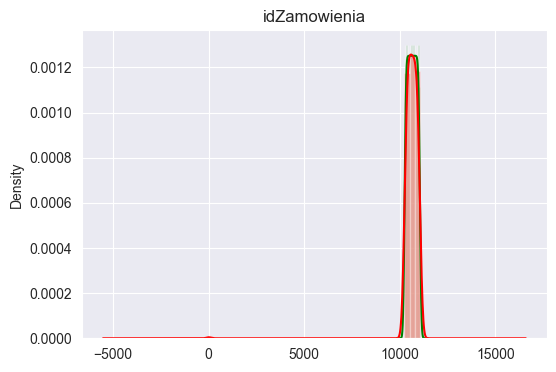

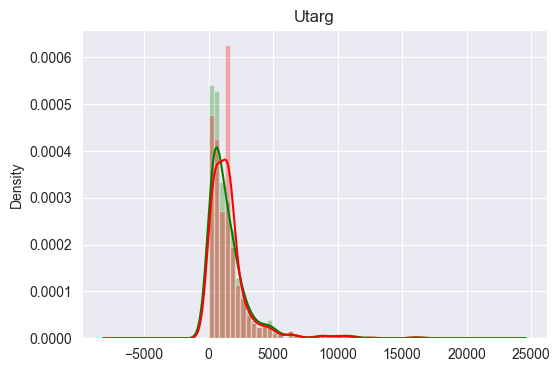

In [41]:
bins = 40
compare_distributions(df, df_copy, bins)

### Zadanie 4

In [48]:
url = "https://raw.githubusercontent.com/YBI-Foundation/Dataset/refs/heads/main/Diabetes%20Missing%20Data.csv"

In [50]:
df_ybi = pd.read_csv(url,sep=',')

In [52]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

numeric_cols = df_ybi.select_dtypes(include=np.number).columns

inputer_data = imputer.fit_transform(df_ybi[numeric_cols])

In [54]:
df_ybi_after_knn_input = pd.DataFrame(inputer_data, columns=numeric_cols)

In [55]:
df_ybi_after_knn_input.head(10)

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6.0,148.0,72.0,35.0,169.0,33.60,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,58.6,26.60,0.351,31.0,0.0
2,8.0,183.0,64.0,25.8,164.6,23.30,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.10,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.10,2.288,33.0,1.0
5,5.0,116.0,74.0,20.6,102.8,25.60,0.201,30.0,0.0
6,3.0,78.0,50.0,32.0,88.0,31.00,0.248,26.0,1.0
7,10.0,115.0,77.6,34.4,132.6,35.30,0.134,29.0,0.0
8,2.0,197.0,70.0,45.0,543.0,30.50,0.158,53.0,1.0
9,8.0,125.0,96.0,26.4,165.8,34.92,0.232,54.0,1.0


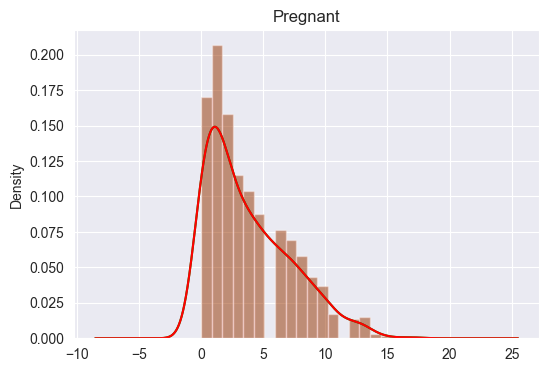

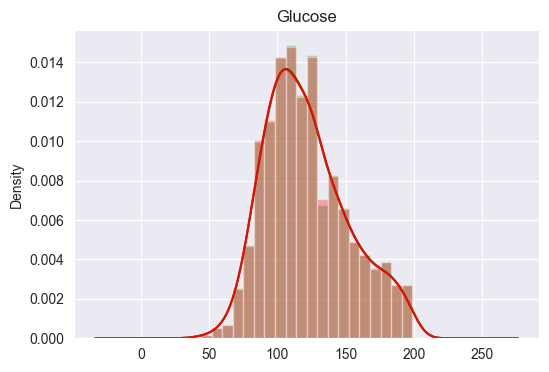

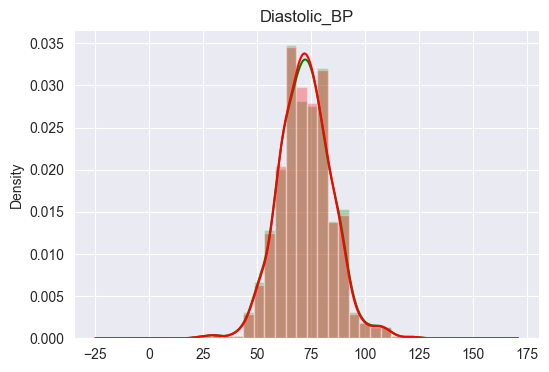

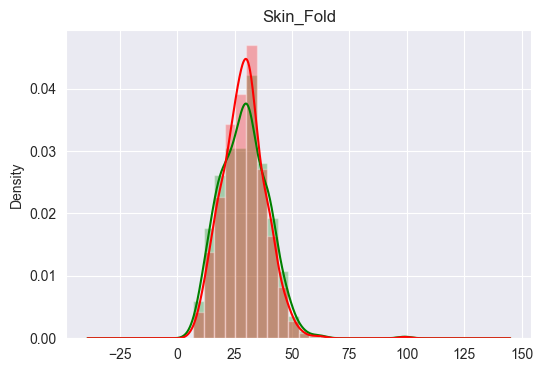

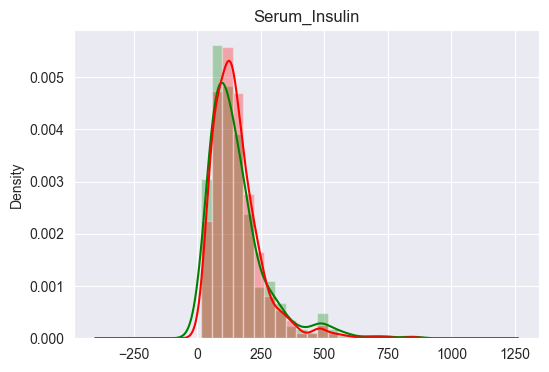

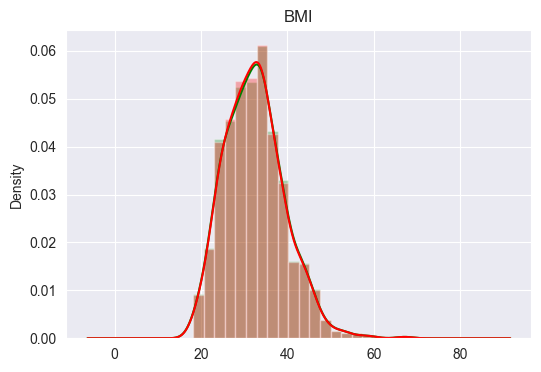

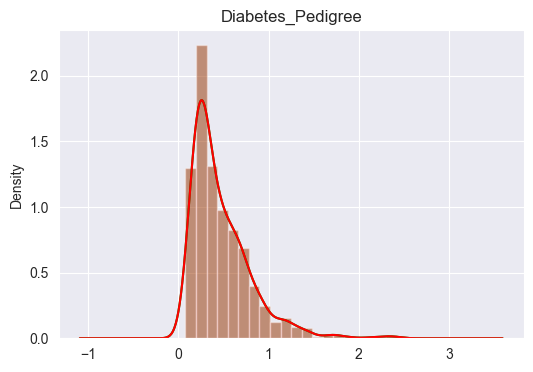

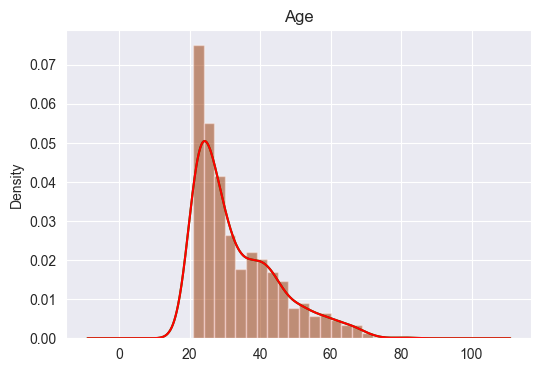

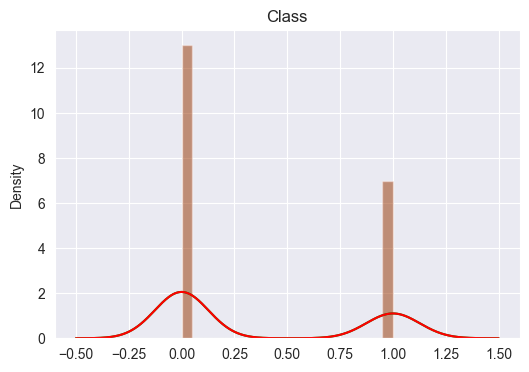

In [56]:
compare_distributions(df_ybi, df_ybi_after_knn_input,20)

### Zadanie 4 – group imputing po Class

In [ ]:
from sklearn.impute import KNNImputer

url = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/refs/heads/main/Diabetes%20Missing%20Data.csv'
df_ybi = pd.read_csv(url, sep=',')

numeric_cols = df_ybi.select_dtypes(include=np.number).columns
imputer = KNNImputer(n_neighbors=5)

df_class_imputed = df_ybi.copy()
for name, group in df_ybi.groupby('Class'):
    idx = group.index
    df_class_imputed.loc[idx, numeric_cols] = imputer.fit_transform(group[numeric_cols])

In [ ]:
compare_distributions(df_ybi, df_class_imputed, 20)

### Zadanie 4 – group imputing po Age

In [ ]:
bins = [0, 18, 30, 50, float('inf')]
labels = ['<18', '18_29', '30_49', '50+']
df_ybi['AgeGroup'] = pd.cut(df_ybi['Age'], bins=bins, labels=labels, right=False)

df_age_imputed = df_ybi.copy()
for name, group in df_ybi.groupby('AgeGroup'):
    idx = group.index
    df_age_imputed.loc[idx, numeric_cols] = imputer.fit_transform(group[numeric_cols])

In [ ]:
compare_distributions(df_ybi, df_age_imputed, 20)